# GIAI ĐOẠN 2: XÂY DỰNG MÔ HÌNH TOÁN HỌC IRT (Item Response Theory)

### 1. Các tham số chính trong Mô hình 2PL
Thay vì đánh giá câu hỏi dựa trên tổng số người làm đúng một cách cảm tính, IRT định lượng bằng các biến số toán học độc lập:

* **Năng lực học sinh (Student Ability - $\theta$):** Năng lực thực chất của học sinh. Tham số này được tính toán dựa trên độ khó của những câu hỏi mà học sinh đó đã vượt qua, thay vì chỉ đếm số lượng câu đúng.
* **Độ khó thực sự của câu hỏi (Question Difficulty - $b$):** Điểm giới hạn mà tại đó học sinh có 50% xác suất trả lời đúng. Tham số độ khó này **độc lập với năng lực của nhóm học sinh làm bài** (loại bỏ được hiện tượng câu hỏi trông có vẻ dễ chỉ vì vô tình rơi vào nhóm học sinh quá giỏi).
* **Độ phân biệt (Discrimination - $a$):** Khả năng của câu hỏi trong việc phân tách rõ ràng giữa học sinh "Giỏi" và "Yếu". Một câu hỏi có độ phân biệt lý tưởng là câu mà học sinh giỏi chắc chắn làm đúng, còn học sinh yếu chắc chắn làm sai (không thể đoán lụi).

### 2. Kế hoạch tính toán (Tiếp cận bằng Proxy)
Để xây dựng mô hình, trước tiên ta cần tính toán các giá trị đại diện (Proxy) ban đầu từ tập dữ liệu lớn:
1. **Ước lượng Proxy Năng lực học sinh:** Tính toán tỷ lệ trả lời đúng tổng thể của từng cá nhân (chỉ lọc xét các học sinh đã làm $\ge$ 10 câu để đảm bảo độ tin cậy của dữ liệu).
2. **Ước lượng Proxy Độ khó câu hỏi:** Tính toán tỷ lệ trả lời sai của từng câu hỏi riêng biệt.

In [3]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('data/train_cleaned.csv')
df_parts = pd.read_csv('data/train_merged_with_parts.csv')

print(f"Đã nạp thành công {len(df_train)} dòng dữ liệu!")
df_train.head()

Đã nạp thành công 99563 dòng dữ liệu!


,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation
0,419,3159614374,12741,9133,0,43,0,0,22000.0,True
1,610,4464214869,12741,7748,0,103,1,1,32750.0,True
2,712,14570276178,13134,1315,0,80,1,0,20000.0,True
3,1485,16570832784,13134,11976,0,709,1,1,19000.0,True
4,1824,17571812750,13134,11968,0,1004,3,1,16000.0,True


### Bước 1.1: Tính toán tỷ lệ đúng của từng học sinh
Nhóm dữ liệu theo từng `user_id` để tính tỷ lệ trả lời đúng trung bình và tổng số câu họ đã làm.

In [18]:
# Gom nhóm toàn bộ dữ liệu theo từng học sinh (user_id)
nhom_hoc_sinh = df_train.groupby('user_id')

# Tính tỷ lệ đúng (mean) và số câu đã làm (count)
student_ability = nhom_hoc_sinh['answered_correctly'].agg(['mean', 'count']).reset_index()
student_ability.rename(columns={'mean': 'ability_score', 'count': 'total_answered'}, inplace=True)

# Tìm giá trị lớn nhất của số câu đã trả lời
max_answered = student_ability['total_answered'].max()
print(max_answered)
student_ability.head()

25


,user_id,ability_score,total_answered
0,12741,0.500000,2
1,13134,0.666667,3
2,24418,1.000000,3
3,91216,0.666667,3
4,107002,1.000000,2


C:\Users\Thy\AppData\Local\Temp\ipykernel_22356\3696260811.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


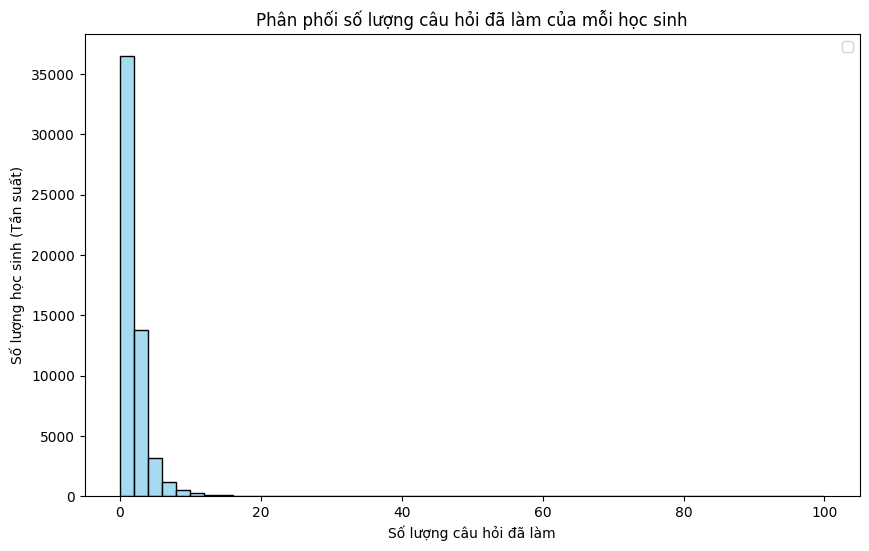

Tổng số học sinh ban đầu: 55568
Nếu lọc >= 10 câu, giữ lại: 0.9%
Nếu lọc >= 20 câu, giữ lại: 0.0%
Nếu lọc >= 30 câu, giữ lại: 0.0%


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ Histogram (Giới hạn xem từ 0 đến 100 câu để nhìn rõ phần đuôi dài)
plt.figure(figsize=(10, 6))
sns.histplot(student_ability['total_answered'], bins=50, binrange=(0, 100), color='skyblue')

plt.title('Phân phối số lượng câu hỏi đã làm của mỗi học sinh')
plt.xlabel('Số lượng câu hỏi đã làm')
plt.ylabel('Số lượng học sinh (Tần suất)')
plt.legend()
plt.show()
 
# In thêm một bảng thống kê nhỏ để xem nếu cắt ở các mốc thì còn lại bao nhiêu % học sinh
total_students = len(student_ability)
print(f"Tổng số học sinh ban đầu: {total_students}")
print(f"Nếu lọc >= 10 câu, giữ lại: {len(student_ability[student_ability['total_answered'] >= 10]) / total_students:.1%}")
print(f"Nếu lọc >= 20 câu, giữ lại: {len(student_ability[student_ability['total_answered'] >= 20]) / total_students:.1%}")
print(f"Nếu lọc >= 30 câu, giữ lại: {len(student_ability[student_ability['total_answered'] >= 30]) / total_students:.1%}")

### Bước 1.2: Lọc dữ liệu nhiễu và Tìm Top học sinh giỏi
Những học sinh chỉ mới làm 1-2 câu mà đúng hết 100% (hoặc sai hết) sẽ làm nhiễu mô hình. Ta cần loại bỏ những học sinh làm dưới 10 câu.